# <font color=darkcyan> MCMC algorithms</font>
#### <font color=darkorange>Metropolis-Hastings, MALA,  Hamiltonian Monte Carlo... </font>

In [37]:
"""""""""""""""""
Required packages
"""""""""""""""""
import seaborn as sns
import autograd.numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
# package which differentiates standard Python and Numpy code
from autograd import grad
# to get progress bars
from tqdm import tqdm
import seaborn as sns
sns.set_theme()

In a Bayesian setting, a parameter $x$ is embedded with a prior distribution $\pi$ and the observations are given by a probabilistic model:

$$
Y\sim \ell(\cdot|x)\,.
$$


The inference is then based on the posterior distribution:
$$
\pi(x|Y) = \frac{\pi(x)\ell(Y|x)}{\int\pi(u)\ell(Y|u)\mathrm{d} u}\,.
$$


In most cases the normalizing constant is not tractable:
$$
\pi(x|Y) \propto \pi(x)\ell(Y|x)\,.
$$

``Markov chain Monte Carlo (MCMC) algorithms`` provide solutions to sample from posterior distributions. ``Hamiltonian Monte Carlo (HMC)`` is a MCMC algorithm that uses gradient information to scale better to higher dimensions. It is used by software like [PyMC3](https://pymc.io/) and [Stan](https://mc-stan.org/). 

Some references on MCMC...
- **Douc R., Moulines E. and Stoffer D.**, Nonlinear time series: theory, methods and applications with R example, 2014, Chapman \& Hall.
- **Michael Betancourt, [A Conceptual Introduction to Hamiltonian Monte Carlo](https://arxiv.org/abs/1701.02434)** A thorough, readable reference that is the main source here

### <font color=darkorange> A few simple models </font>

In the following, the target density is written $\pi$. We define below two examples of target densities $\pi$ which will be used to assess the efficiency of the proposed MCMC algorithm.

<font color=darkred> Write a function returning the opposite of the log probability density of </font>
    
<font color=darkred>    i) a Gaussian random variable with mean mu and covariance matrix sigma; </font>
    
<font color=darkred>    ii) a mixture of probability density functions. </font>

In [59]:
def multi_gauss(mu, sigma):
    """
    Inputs
    ----------
    mu: mean of the Gaussian distribution
    sigma: covariance matrix of the Gaussian distribution
    
    Outputs
    -------
    logp: opposite of the loglikelihood
    """    
    sigma_inv = np.linalg.inv(sigma)

    def logp(x):
        diff = x - mu
        lp = 0.5 * diff @ sigma_inv @ diff
        return lp
    return logp

def mixture(log_prob, weights):
    """
    Inputs
    ----------
    log_prob: opposite of the likelihood of each term
    weights: weights of the components of the mixture
    
    Outputs
    -------
    logp: opposite of the loglikelihood of the mixture
    """
    weights = np.array(weights)
    def logp(x):
        log_prob_ev = np.array([lp(x) for lp in log_prob])
        marg = np.exp(-log_prob_ev)
        marg_w = np.dot(marg, weights)
        lp = -np.log(marg_w)
        return lp
    
    return logp

In [4]:
grid_lim = 6
# grid on which the target pdf is displayed
grid_plot = (-grid_lim, grid_lim, -grid_lim, grid_lim)
# coordinates chosen on this grid
nb_points = 100

xplot = np.linspace(-grid_lim, grid_lim, nb_points)
yplot = np.linspace(-grid_lim, grid_lim, nb_points)
Xplot, Yplot = np.meshgrid(xplot, yplot)

## <font color=darkcyan> Metropolis-Hastings algorithm </font>

``Objective target density:`` $\pi(\cdot|Y)$.

``Instrumental transition density:`` $q(x,y)$.

At each iteration $k\geqslant 0$, generate $Z_{k+1} \sim q(X_k,\cdot)$.

Set $X_{k+1} = Z_{k+1}$ with probability $\alpha(X_k,Z_{k+1})$ and  $X_{k+1} = X_k$ with probability $1-\alpha(X_k,Z_{k+1})$, where 

$$
\alpha(x,y) = 1\wedge\frac{\pi(y|Y)}{\pi(x|Y)}\frac{q(y,x)}{q(x,y)}\,.
$$

<font color=darkred> Write a function which returns samples from Metropolis-Hastings algorithm with Gaussian proposal density.</font>

In [5]:
def HM_monte_carlo(n_samples, log_prob, initial_state, step_size = 0.1):
    """
    Inputs
    ----------
    n_samples: number of samples to return
    log_prob: opposite of the loglikelihood to sample from
    initial_state: initial sample
    step_size: standard deviation of the proposed moves
    
    Outputs
    -------
    samples: samples from the MCMC algorithm
    accepted: array of 0 and 1 to display which proposed moves have been accepted
    """
    initial_state = np.array(initial_state)
    
    samples  = [initial_state]
    accepted = []

    size = (n_samples,) + initial_state.shape[:1]
    
    # random variable to sample proposed moves
    epsilon = stats.norm(0, 1).rvs(size)
    
    for noise in tqdm(epsilon):
        u = stats.uniform.rvs()
        x = samples[-1]
        y = x + step_size * noise
        threshold = min(1,np.exp(-log_prob(y))/np.exp(-log_prob(x)))
        if(u<=threshold):
            samples.append(y)
            accepted.append(1)
        else:
            samples.append(x)
            accepted.append(0)

    return (np.array(samples[1:]),np.array(accepted),)

## <font color=darkcyan> Metropolis Adjusted Langevin algorithm (MALA) </font>

``Objective target density:`` $\pi(\cdot|Y)$.

At each iteration $k\geqslant 0$, generate $Z_{k+1} \sim X_k + \frac{\sigma^2}{2}\nabla\log\pi(X_k|Y) + \sigma \varepsilon_{k+1}$.

Set $X_{k+1} = Z_{k+1}$ with probability $\alpha(X_k,Z_{k+1})$ and  $X_{k+1} = X_k$ with probability $1-\alpha(X_k,Z_{k+1})$, where 

$$
\alpha(x,y) = 1\wedge\frac{\pi(y|Y)}{\pi(x|Y)}\frac{q(y,x)}{q(x,y)}\,,
$$

where $q(x,y)$ is the Gaussian pdf with mean $x + \frac{\sigma^2}{2}\nabla\log\pi(x|Y)$ and variance $\sigma^2 I_d$.

<font color=darkred> Write a function which returns samples from MALA algorithm.</font>

In [7]:
def MALA_monte_carlo(n_samples, log_prob, initial_state, step_size = 0.1):
    """
    Inputs
    ----------
    n_samples: number of samples to return
    log_prob: opposite of the loglikelihood to sample from
    initial_state: initial sample
    step_size: standard deviation of the proposed moves
    
    Outputs
    -------
    samples: samples from the MCMC algorithm
    accepted: array of 0 and 1 to display which proposed moves have been accepted
    """
    initial_state = np.array(initial_state)

    gradV = grad(log_prob)

    samples  = [initial_state]
    accepted = []

    size = (n_samples,) + initial_state.shape[:1]
    
    # random variable to sample proposed moves
    epsilon = stats.norm(0, 1).rvs(size)
    
    for noise in tqdm(epsilon):
        u = stats.uniform.rvs()
        x = samples[-1]
        y = x + step_size**2/2 * grad(-log_prob(x)) + step_size * noise
        qxy = stats.norm.pdf(y, loc=x + step_size**2/2 * grad(-log_prob(x)), scale=step_size)
        qyx = stats.norm.pdf(x, loc=y + step_size**2/2 * grad(-log_prob(y)), scale=step_size)

        threshold = min(1,np.exp(-log_prob(y))*qyx/(np.exp(-log_prob(x))*qxy))
        if(u<=threshold):
            samples.append(y)
            accepted.append(1)
        else:
            samples.append(x)
            accepted.append(0)
        
        

    return (np.array(samples[1:]),np.array(accepted),)

## <font color=darkcyan> Hamiltonian Monte Carlo </font>

### <font color=darkorange> Framework </font>

The unknown  parameters are gathered into a _position_ variable, usually written $\mathbf{q}$. 
An auxiliary variable, called ``momentum`` and written $\mathbf{p}$, is introduced to define the extended joint probability distribution 

$$
\pi(\mathbf{q}, \mathbf{p}|Y) =  \pi(\mathbf{q}|Y) \pi(\mathbf{p} | \mathbf{q},Y)\,,
$$

In most cases $\pi(\mathbf{p} | \mathbf{q},Y)$ is the probability density of a Gaussian random variable with mean $0$ and variance $M$.

The ``Hamiltonian`` associated with this model is  $H(\mathbf{q}, \mathbf{p}|Y) = -\log \pi(\mathbf{q}, \mathbf{p}|Y)$ so that

$$
H(\mathbf{q}, \mathbf{p}|Y) = -\log \pi(\mathbf{p} | \mathbf{q},Y) - \log \pi(\mathbf{q}|Y) = K(\mathbf{p}, \mathbf{q}|Y) + V(\mathbf{q}|Y)\,,
$$

where $K(\mathbf{p}, \mathbf{q}|Y)$ is called the _kinetic energy_, and $V(\mathbf{q}|Y)$ is called the _potential energy_.

The dynamics of the system $(\mathbf{q}, \mathbf{p})$ is assumed to follow _Hamilton's equations_:

$$
\frac{\mathrm{d} \mathbf{q}}{\mathrm{d}t} = \frac{\partial H}{\partial \mathbf{p}} = \frac{\partial K}{\partial \mathbf{p}} + \frac{\partial V}{\partial \mathbf{p}}\\
\frac{\mathrm{d} \mathbf{p}}{\mathrm{d}t} = -\frac{\partial H}{\partial \mathbf{q}}= -\frac{\partial K}{\partial \mathbf{q}} + \frac{\partial V}{\partial \mathbf{q}}
$$


When $\pi(\mathbf{p} | \mathbf{q},Y)$ is the probability density of a Gaussian random variable with mean $0$ and variance $M$, this yields

$$
K(\mathbf{p}, \mathbf{q}) = \frac{1}{2}\mathbf{p}^T M^{-1}\mathbf{p} + \log |M| + \text{C},
$$

In the specific case of $M=I$,  
$$
K(\mathbf{p}, \mathbf{q}) = \frac{1}{2}\mathbf{p}^T \mathbf{p} + \text{C}\,,
$$

so that

$$
\frac{\partial K}{\partial \mathbf{p}} = \mathbf{p} \quad \mathrm{and} \quad \frac{\partial K}{\partial \mathbf{q}} = \mathbf{0}\,.
$$


Finally,

$$
\frac{\mathrm{d} \mathbf{q}}{\mathrm{d}t}  = \mathbf{p}\quad \mathrm{and} \quad \frac{\mathrm{d} \mathbf{p}}{\mathrm{d}t} = - \frac{\partial V}{\partial \mathbf{q}}\,.
$$

<font color=darkred> Write a function returning the positions and momemtums of a Euler scheme based interator </font>

In [11]:
def euler_integrator(q, p, gradientV, T, step):
    """
    Inputs
    ----------
    q: initial position
    p: initial momentum
    gradientV: gradient of the velocity
    T: time horizon
    step: step size to discretize the ODE
    
    Outputs
    -------
    q, p: last position and last momentum
    posisions: sequence of positions produced by the Euler based scheme integrator
    momentums: sequence of momentums produced by the Euler based scheme integrator
    """
    
    q, p      = np.copy(q), np.copy(p)
    pos, moms = [np.copy(q)], [np.copy(p)]

    vq = gradientV(q)
    nb_steps = int(T / step)
    
    for it in range(nb_steps):
        q += step * p
        p -= step * vq
        pos.append(np.copy(q))
        moms.append(np.copy(p))
        vq = gradientV(q)
        

    return q, -p, np.array(pos), np.array(moms)

### <font color=darkorange> The Leapfrog integrator </font>
The leapfrog integrator may be used to approximate the ordinary differential equations (ODE) $q$ and $p$ are solutions to. 

It involves updating the momentum `p` a half step, then the position `q` a whole step, and then finish updating `p` the other half of the step.

A momentum flip at the end is required to preserve the reversibility of the algorithm.

<font color=darkred> Write a function returning the positions and momemtums of a leapfrog interator </font>

In [23]:
def leapfrog_integrator(q, p, gradientV, T, step):
    """
    Inputs
    ----------
    q: initial position
    p: initial momentum
    gradientV: gradient of the velocity
    T: time horizon
    step: step size to discretize the ODE
    
    Outputs
    -------
    q, p: last position and last momentum
    posisions: sequence of positions produced by the leapfrog integrator
    momentums: sequence of momentums produced by the leapfrog integrator
    """
    
    q, p      = np.copy(q), np.copy(p)
    pos, moms = [np.copy(q)], [np.copy(p)]

    vq = gradientV(q)
    nb_steps = int(T / step)
    
    for it in range(nb_steps):
        p -= step/2*vq
        q += step*p
        vq = gradientV(q)
        p -= step/2*vq
        pos.append(np.copy(q))
        moms.append(np.copy(p))

    return q, -p, np.array(pos), np.array(moms)

<font color=darkred> Illustrate the points proposed by the leapfrog integrator along a trajectory for a 2-dimensional Gaussian distribution. </font>

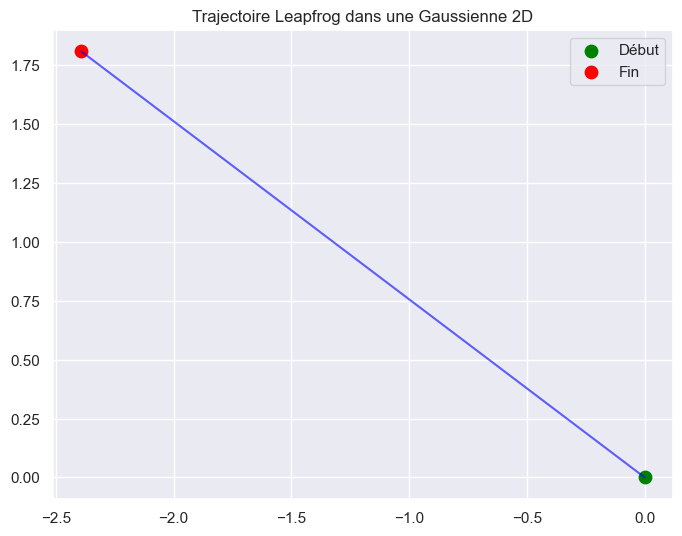

In [39]:
log_density = multi_gauss(np.zeros(2), np.eye(2))
gradV = grad(log_density)

M = 2*np.eye(2)
ini_p = stats.multivariate_normal.rvs(mean=(0,0), cov=M)
q, p, samples, momentums = leapfrog_integrator(np.zeros(2), ini_p, gradV, 1, 0.001)

fig, ax = plt.subplots(figsize=(8, 8))

# Trajectoire
ax.plot(samples[:,0], samples[:,1], color="blue", alpha=0.6)

# Point initial
ax.scatter(samples[0,0], samples[0,1], s=80, color="green", label="Début")

# Point final
ax.scatter(samples[-1,0], samples[-1,1], s=80, color="red", label="Fin")

ax.set_aspect("equal")
ax.set_title("Trajectoire Leapfrog dans une Gaussienne 2D")
ax.legend()

plt.show()



<font color=darkred> Display several trajectories of the leapfrog integrator for a 2-dimensional Gaussian target distribution. </font>

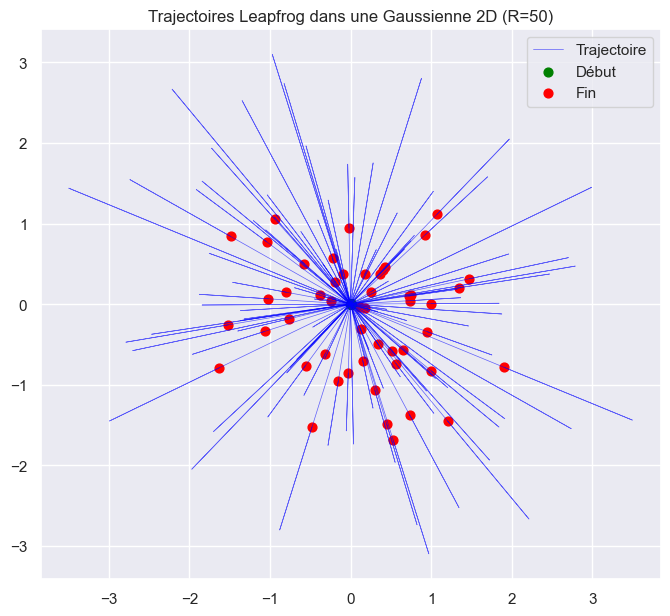

In [ ]:
log_density = multi_gauss(np.zeros(2), np.eye(2))
gradV = grad(log_density)

M = 2*np.eye(2)
ini_p = stats.multivariate_normal.rvs(mean=(0,0), cov=M)
N = 50

fig, ax = plt.subplots(figsize=(8, 8))
for i in range(R):
    ini_p = stats.multivariate_normal.rvs(mean=(0,0), cov=M)
    q, p, samples, momentums = leapfrog_integrator(np.zeros(2), ini_p, gradV, 10, 0.01)
    ax.plot(samples[:,0], samples[:,1], color="blue", alpha=0.6, label="Trajectoire" if i == 0 else "", linewidth=0.5)
    ax.scatter(samples[0,0], samples[0,1], s=40, color="green", label="Début" if i == 0 else "")
    ax.scatter(samples[-1,0], samples[-1,1], s=40, color="red", label="Fin" if i == 0 else "")
ax.set_title(f"Trajectoires Leapfrog dans une Gaussienne 2D (N={N})")
ax.legend()
ax.set_aspect("equal")
plt.show()


<font color=darkred> Display several trajectories of the leapfrog integrator for a target defined as a mixture of 2-dimensional Gaussian distributions. </font>

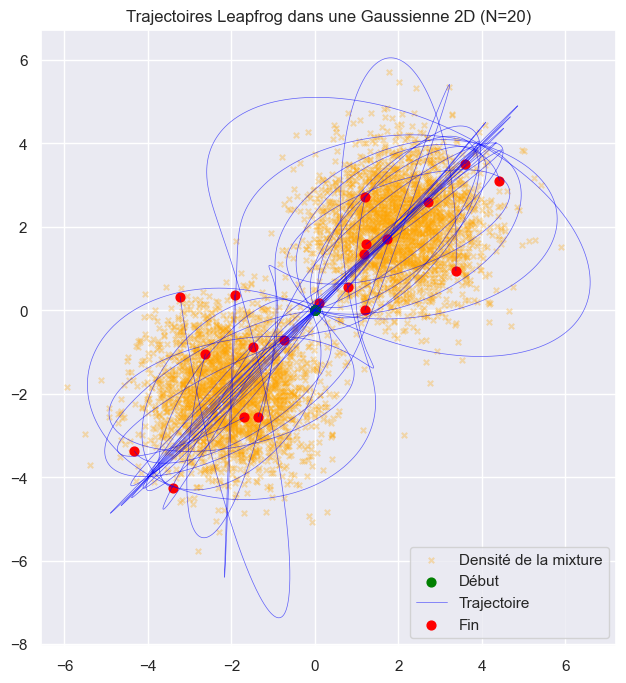

In [69]:
log_density = mixture([multi_gauss(np.array([-2, -2]), np.eye(2)), multi_gauss(np.array([2, 2]), np.eye(2))], weights=[0.5, 0.5])
gradV = grad(log_density)

M = 2*np.eye(2)
ini_p = stats.multivariate_normal.rvs(mean=(0,0), cov=M)
N = 20

fig, ax = plt.subplots(figsize=(8, 8))

n_samples = 5000
samples_mix = np.zeros((n_samples, 2))
for i in range(n_samples):
    if np.random.rand() < 0.5:
        samples_mix[i] = stats.multivariate_normal.rvs(mean=[-2, -2], cov=np.eye(2))
    else:
        samples_mix[i] = stats.multivariate_normal.rvs(mean=[ 2,  2], cov=np.eye(2))

ax.scatter(samples_mix[:,0], samples_mix[:,1], s=15, alpha=0.3, color="orange", marker='x', label="Densité de la mixture")

for i in range(N):
    ini_p = stats.multivariate_normal.rvs(mean=(0,0), cov=M)
    q, p, samples, momentums = leapfrog_integrator(np.zeros(2), ini_p, gradV, 10, 0.01)
    ax.scatter(samples[0,0], samples[0,1], s=40, color="green", label="Début" if i == 0 else "")
    ax.plot(samples[:,0], samples[:,1], color="blue", alpha=0.6, label="Trajectoire" if i == 0 else "", linewidth=0.5)
    ax.scatter(samples[-1,0], samples[-1,1], s=40, color="red", label="Fin" if i == 0 else "")
ax.set_title(f"Trajectoires Leapfrog dans une Gaussienne 2D (N={N})")
ax.legend()
ax.set_aspect("equal")
plt.show()


### <font color=darkorange> The Hamiltonian loop </font>

<font color=darkred> Use the leapfrog function to write a Hamiltonian loop i.e. a Hamiltonian MCMC with a generic target distribution. </font>

In [107]:
def hamiltonian_monte_carlo(n_samples, log_prob, initial_position, T = 1, step_size = 0.1):
    """
    Inputs
    ----------
    n_samples: number of samples to return.
    log_prob: opposite of the target log probability.
    initial_position: a place to start sampling from.
    T: length of leapfrog integration.
    step_size: step size of the integration scheme.
    
    Outputs
    -------
    samples: samples produced by the HMC.
    sample_positions: positions obtained by the leapfrog integrator at each time step.
    sample_momentums: momentums obtained by the leapfrog integrator at each time step.
    accepted: array of 0 and 1 to display which proposed moves have been accepted.
    """
    initial_position = np.array(initial_position)
    
    gradV = grad(log_prob)

    samples = [initial_position]
    sample_positions, sample_momentums = [], []
    accepted = []

    size = (n_samples,) + initial_position.shape[:1]
    
    # all momentums
    momentum = st.norm(0, 1).rvs(size)
    
    for p0 in tqdm(momentum):
        #
        #
        #
        #

    return (np.array(samples[1:]),np.array(sample_positions),np.array(sample_momentums),np.array(accepted),)

<font color=darkred> Display several trajectories of the HMC loop for a Gaussian target distribution </font>

<font color=darkred>i) Illustrate the influence of the total length of the leapfrog integrator. </font>

<font color=darkred>ii) Illustrate the influence of the step size of the leapfrog integrator. </font>

<font color=darkred>iii) Compare the performance with a HM algorithm. </font>

<font color=darkred>iv) Compare the performance with a MALA algorithm. </font>

<font color=darkred> Display several trajectories of the HMC algorithm for a target defined as a mixture of Gaussian distributions. </font>

<font color=darkred>i) Illustrate the influence of the total length of the leapfrog integrator. </font>

<font color=darkred>ii) Illustrate the influence of the step size of the leapfrog integrator. </font>

<font color=darkred>iii) Compare the performance with a HM algorithm. </font>

<font color=darkred>iv) Compare the performance with a MALA algorithm. </font>

### <font color=darkorange> Parameters tuning </font>

<font color=darkred>Analyze the optimal tuning of the HMC parameters: variance matrix of the momentums, step-size, length of the symplectic integration...</font>